# Prediction Layout Visualization

This notebook only focuses on the graph layout for many predictions:
- Bayesian Label
- NN Prediction
- Difference (Label - Prediction)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path

Using model: models/cnn/cnn_small_20260415_041046/model.keras
Using dataset: data/hard/2026_04_13_22_30_24_minesweeper_hard_65536_123.npz
x shape=(65536, 16, 30), y shape=(65536, 16, 30), mask shape=(65536, 16, 30)


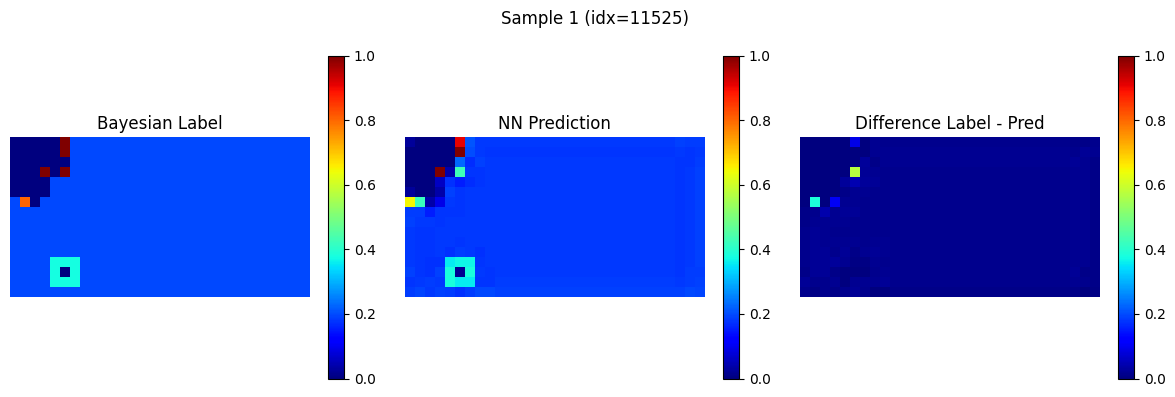

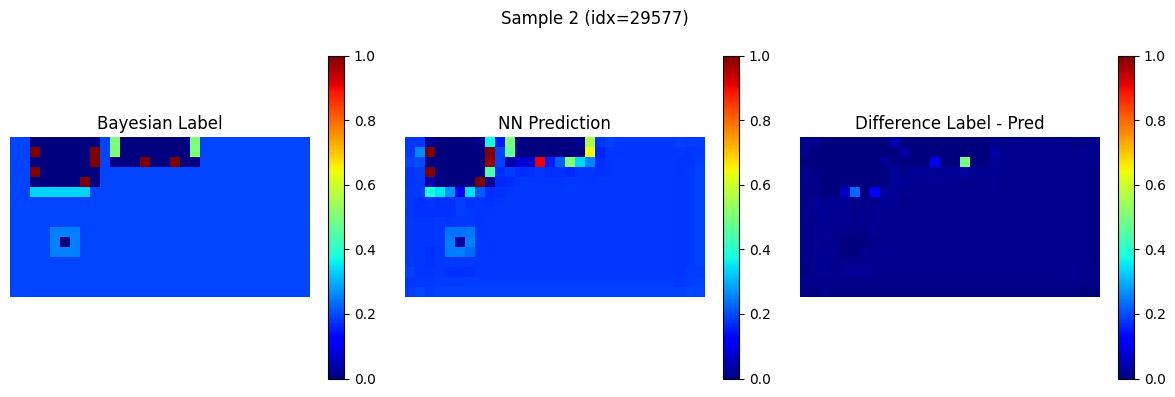

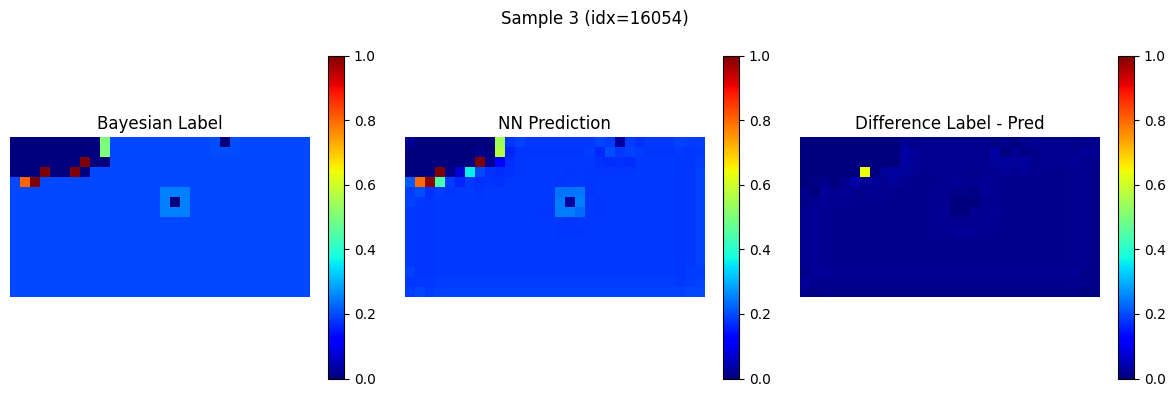

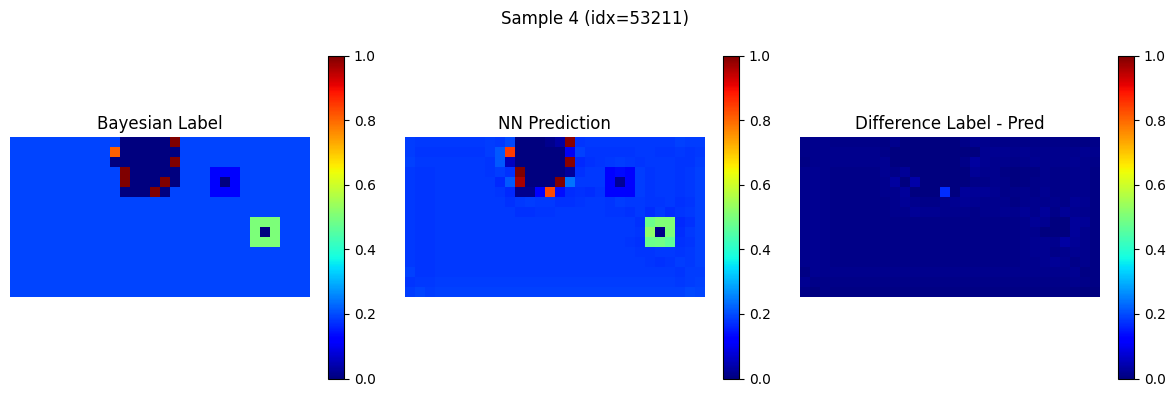

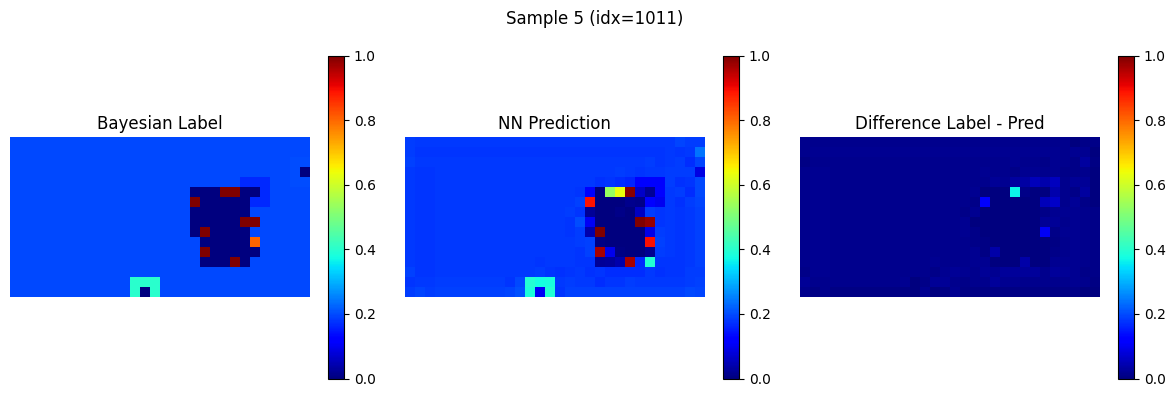

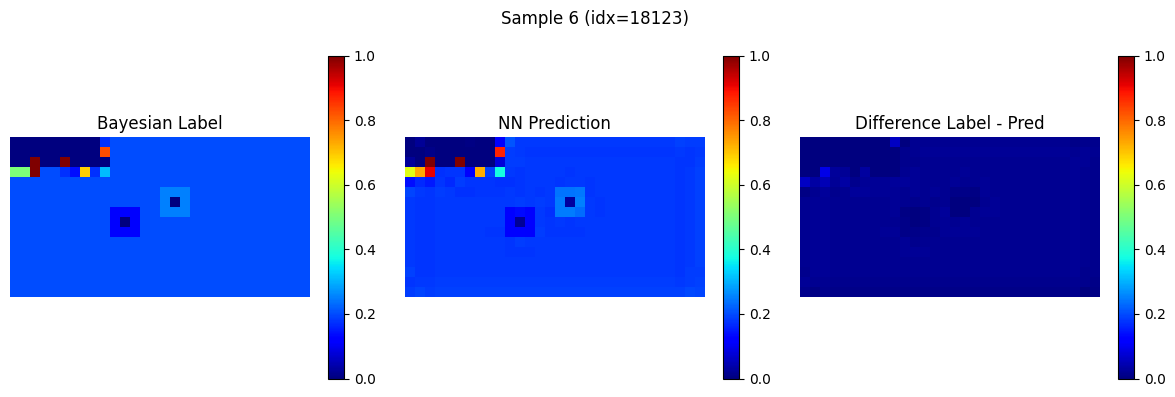

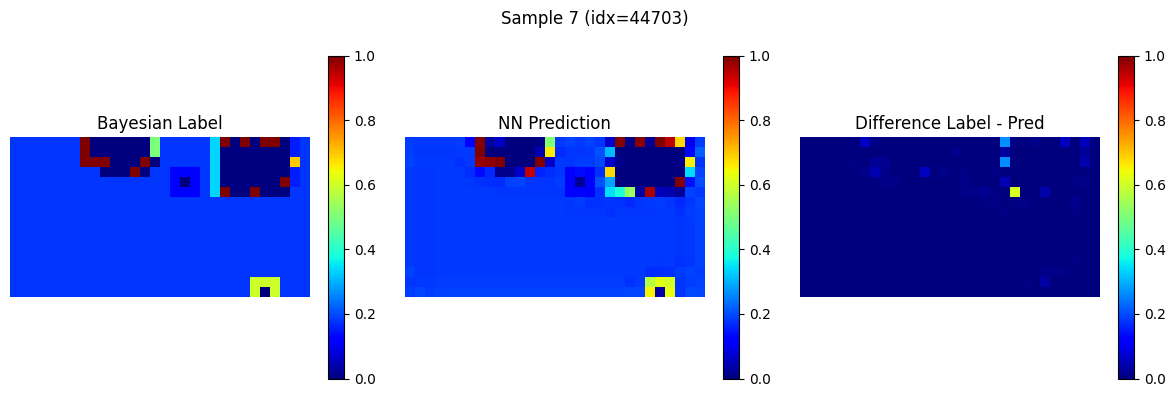

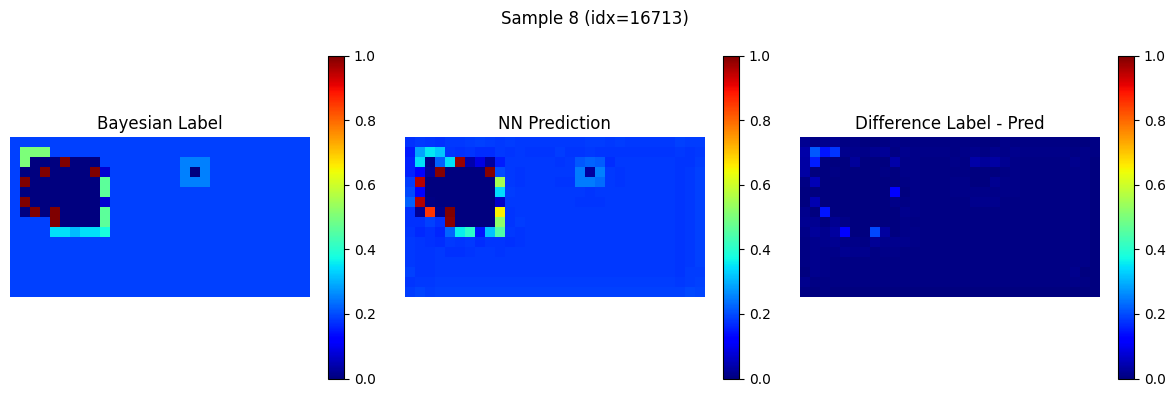

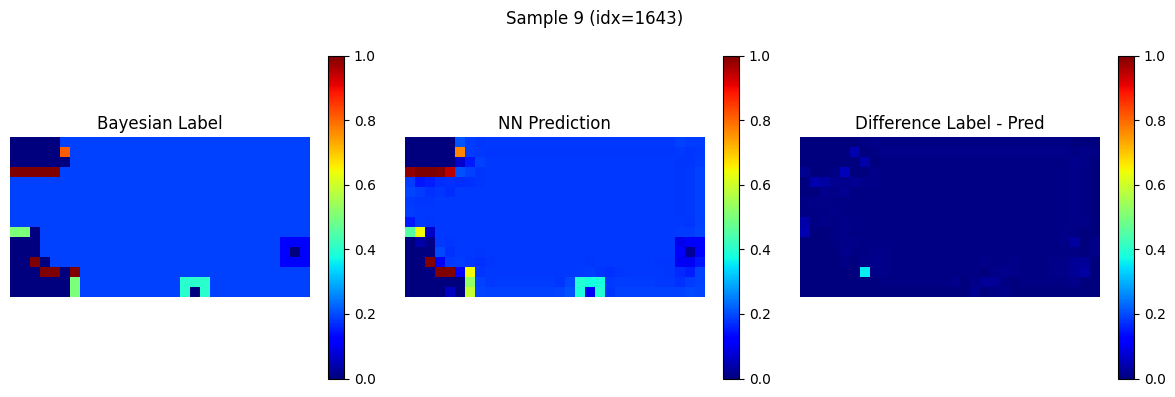

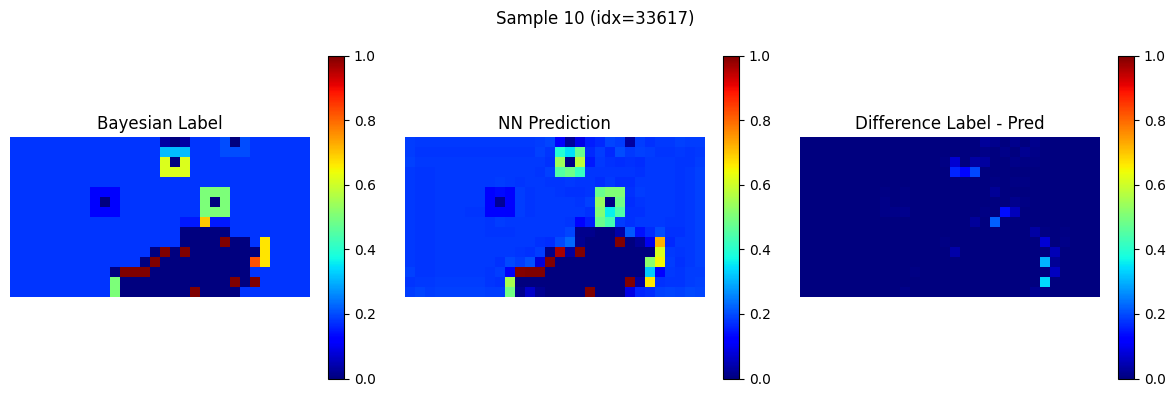

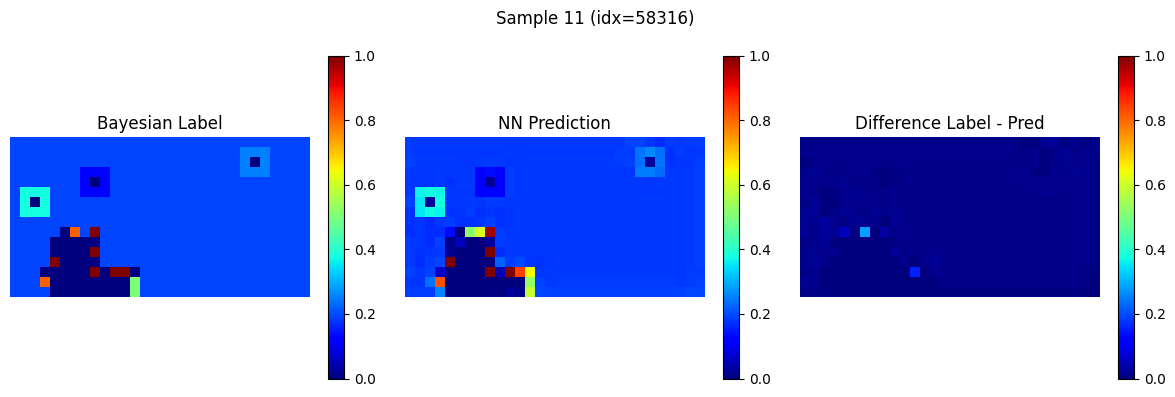

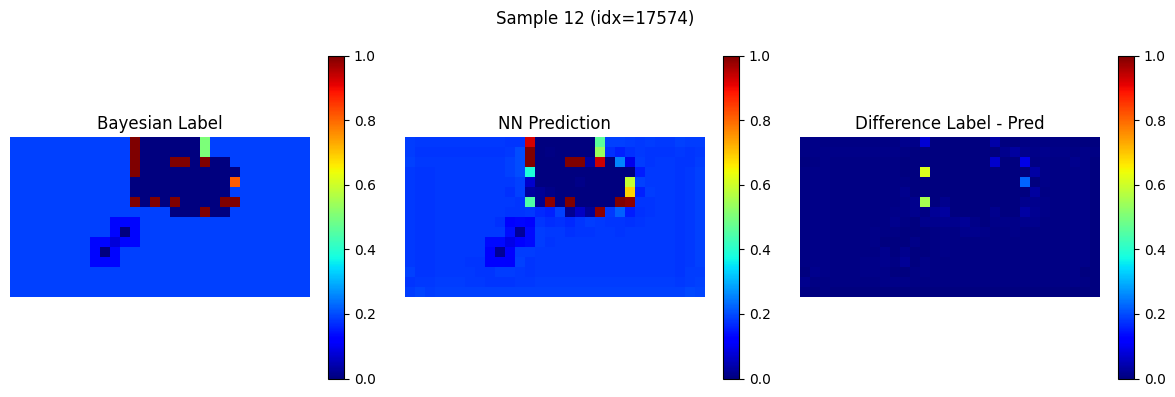

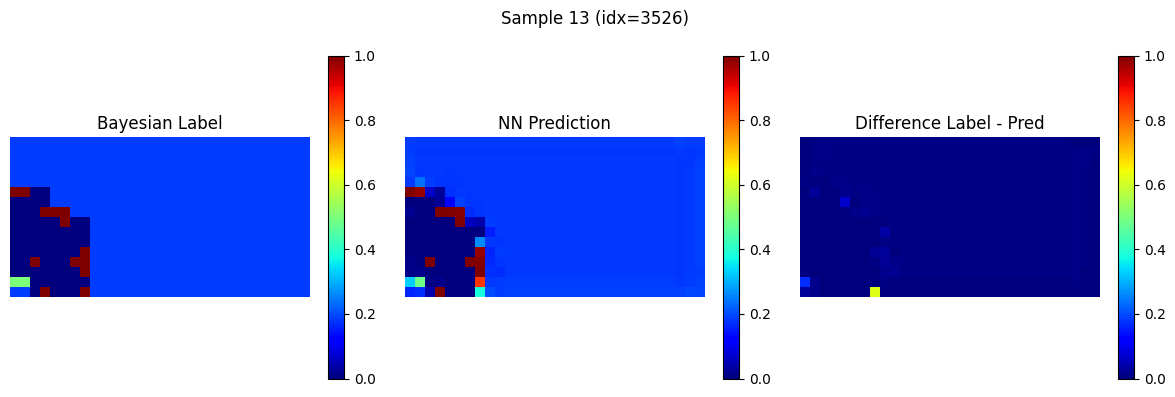

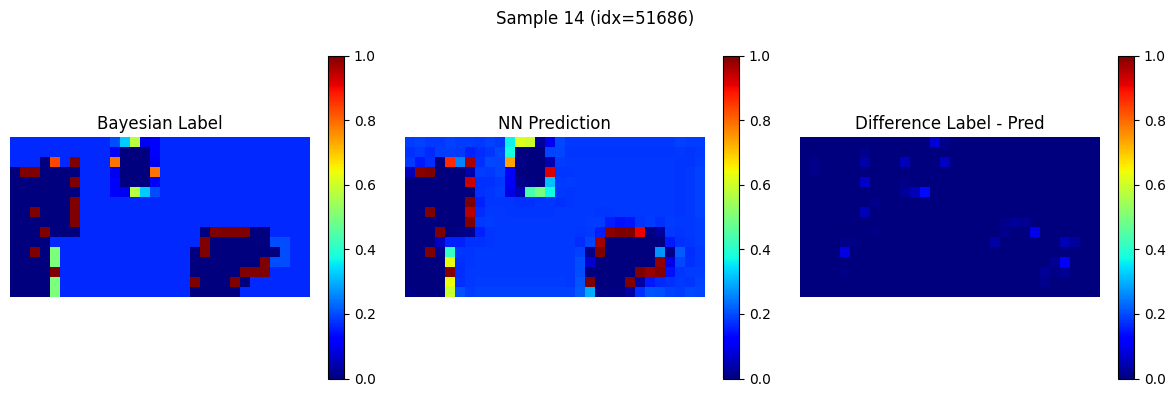

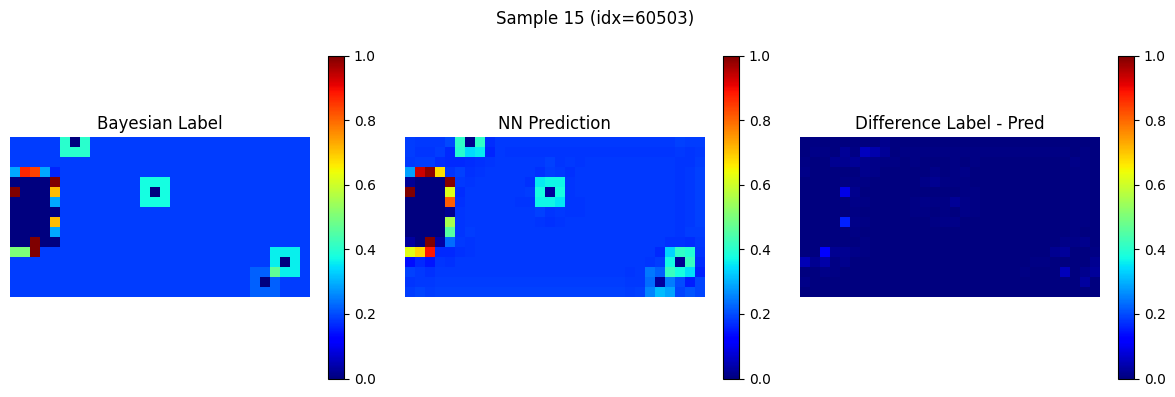

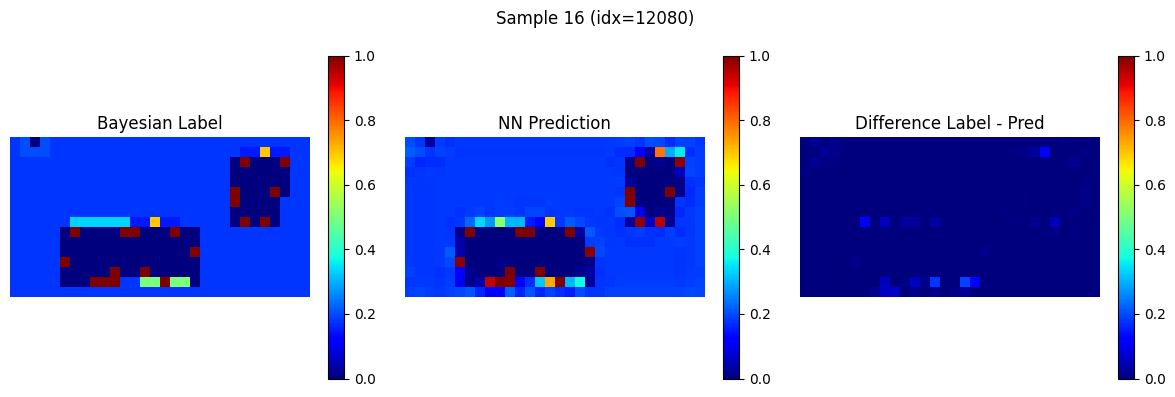

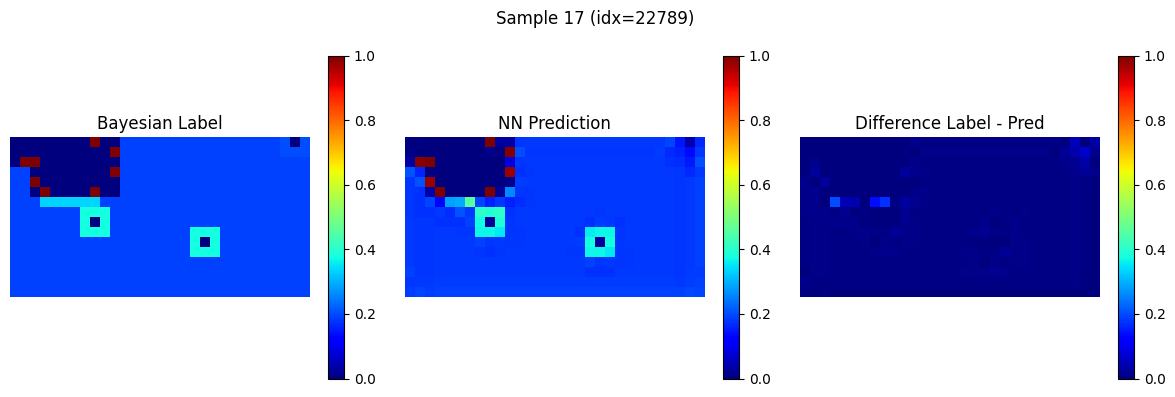

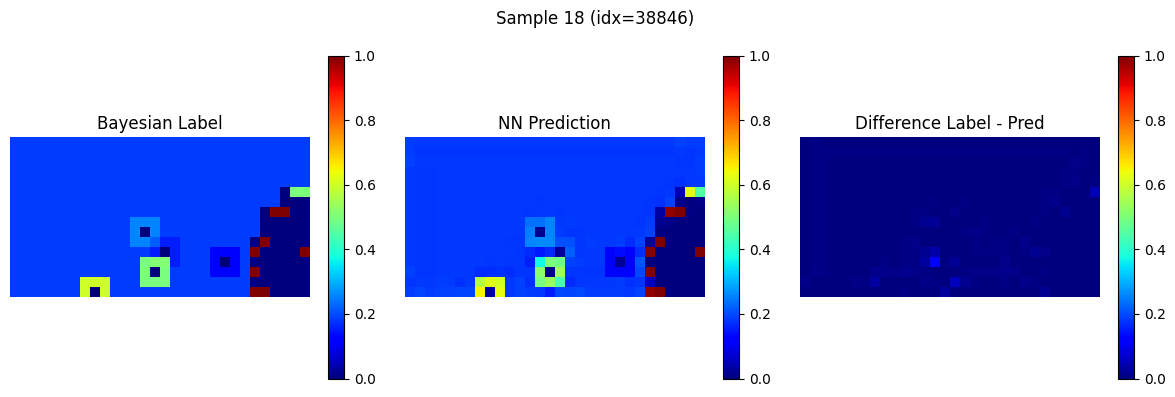

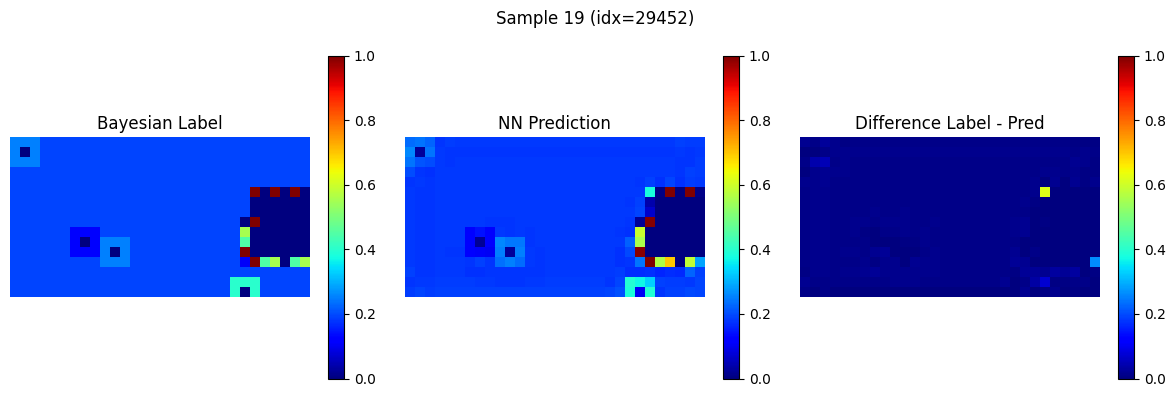

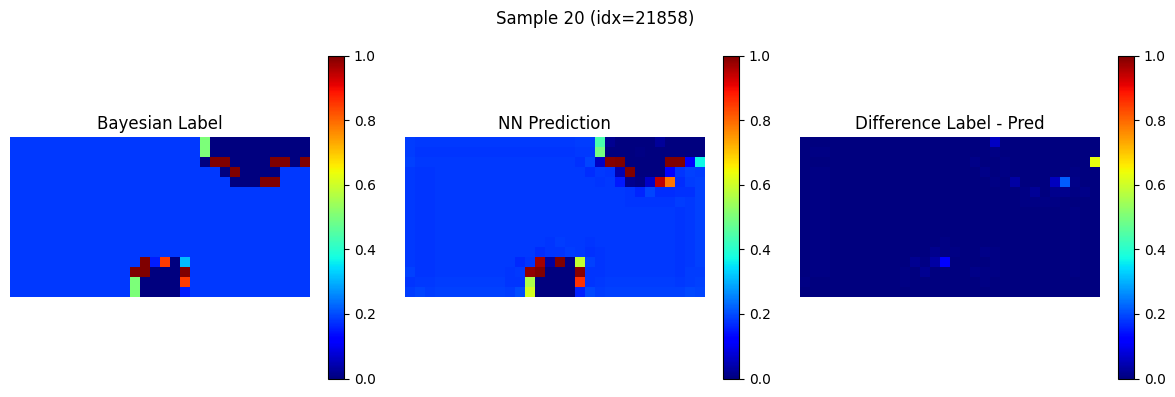

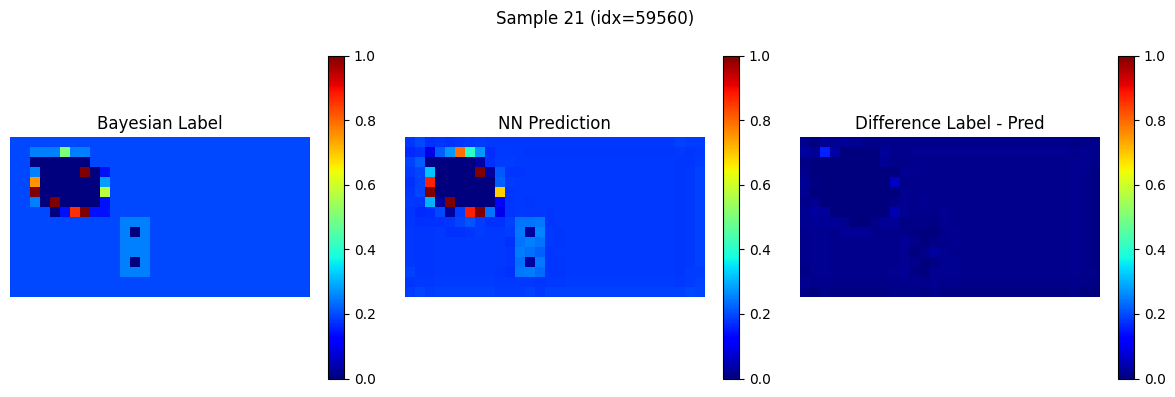

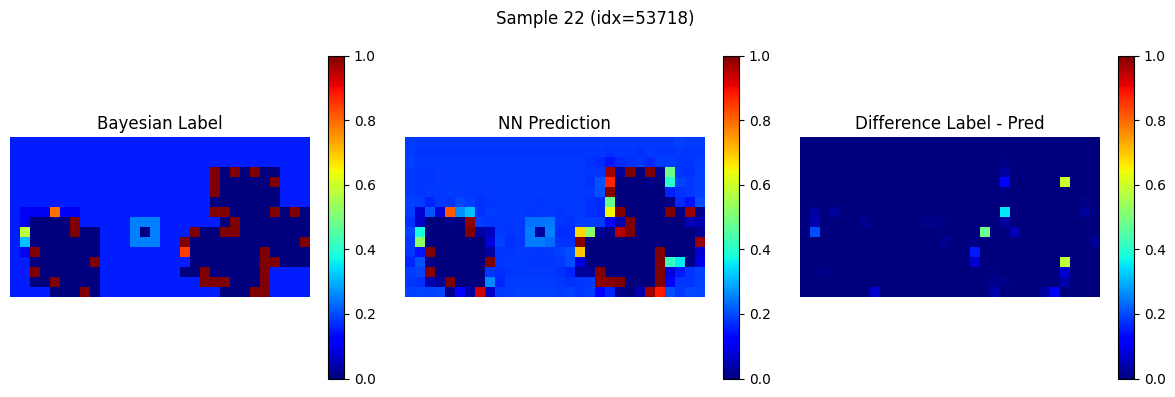

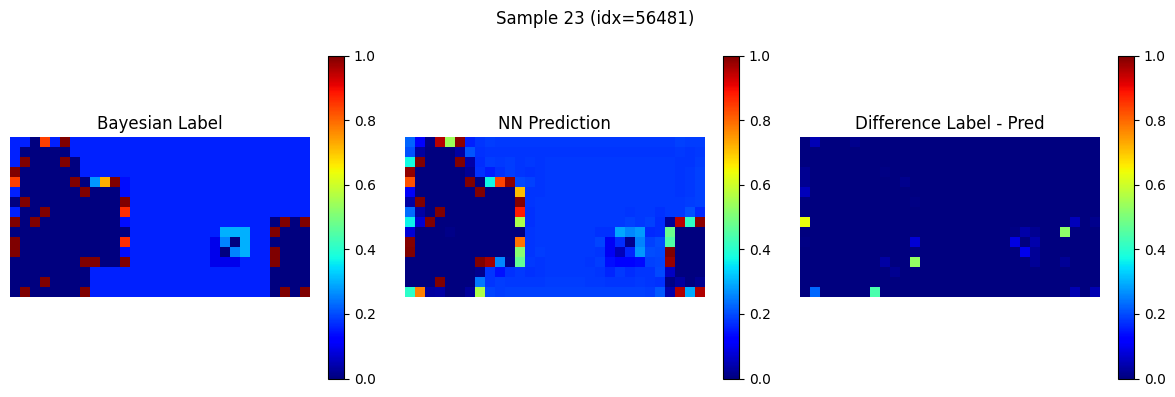

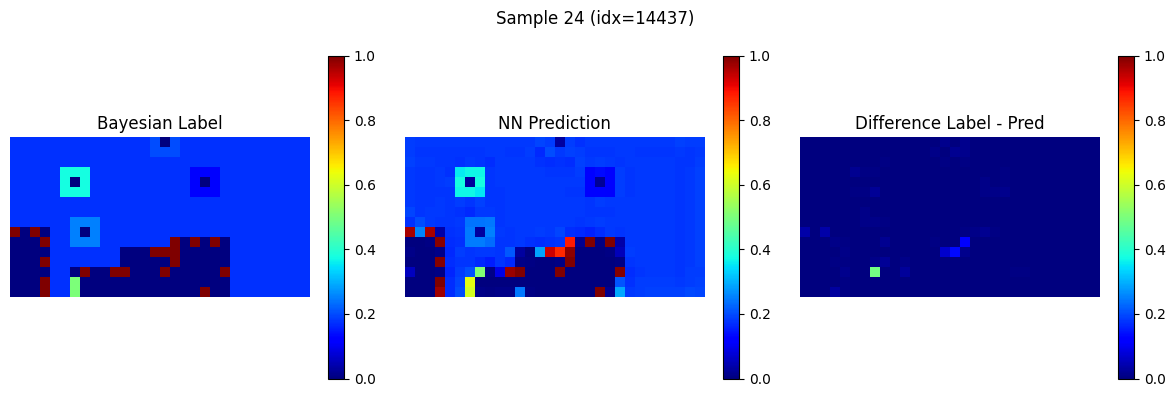

In [3]:
# --- Config ---
data_dir = Path("data/hard")
dataset_no = 0
model_root = Path("models/cnn")
max_plots = 24
random_seed = 123


# --- Load model ---
# Picks newest model saved under models/cnn/*/model.keras.
model_candidates = sorted(model_root.glob("*/model.keras"), key=lambda p: p.stat().st_mtime)
if not model_candidates:
    raise FileNotFoundError(f"No model found in {model_root}. Expected e.g. models/cnn/<run>/model.keras")

model_path = model_candidates[-1]
print(f"Using model: {model_path}")
model = tf.keras.models.load_model(model_path, compile=False)


# --- Load dataset ---
file_paths = sorted([p for p in data_dir.iterdir() if p.suffix == ".npz"])
if not file_paths:
    raise FileNotFoundError(f"No .npz files found in {data_dir}")
if dataset_no < 0 or dataset_no >= len(file_paths):
    raise IndexError(f"dataset_no={dataset_no} out of range 0..{len(file_paths)-1}")

data_path = file_paths[dataset_no]
print(f"Using dataset: {data_path}")

data = np.load(data_path, allow_pickle=False)
x = data["x"].astype(np.float32)
y = data["y"].astype(np.float32)
mask = data["mask"].astype(np.bool_)

print(f"x shape={x.shape}, y shape={y.shape}, mask shape={mask.shape}")


# --- Same preprocessing as train_cnn.py ---
# Covered stays -1.0, uncovered clues (0..8) become [0..1].
x_in = np.where(x < 0, -1.0, x / 8.0).astype(np.float32)
x_in = np.expand_dims(x_in, axis=-1)   # (B, N, M, 1)
y_in = np.expand_dims(y, axis=-1)       # (B, N, M, 1)


# --- Build test_samples list ---
rng = np.random.default_rng(random_seed)
num_available = x_in.shape[0]
num_show = min(max_plots, num_available)
indices = rng.choice(num_available, size=num_show, replace=False)
test_samples = [(x_in[idx], y_in[idx]) for idx in indices]


# --- Plot layout for many samples ---
for i, (board_input, label) in enumerate(test_samples):
    # board_input: shape (N, M, 1)
    # label:       shape (N, M, 1)

    board_input_expanded = board_input[np.newaxis, ...]  # (1, N, M, 1)
    prediction = model.predict(board_input_expanded, verbose=0)  # (1, N, M, 1)

    prediction_2d = prediction[0, ..., 0]  # (N, M)
    label_2d = label[..., 0]               # (N, M)

    # Difference map: (Bayesian Label) - (NN Prediction)
    diff_2d = label_2d - prediction_2d

    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    plt.suptitle(f"Sample {i + 1} (idx={indices[i]})")

    im1 = axs[0].imshow(label_2d, cmap="jet", vmin=0, vmax=1)
    axs[0].set_title("Bayesian Label")
    axs[0].axis("off")
    fig.colorbar(im1, ax=axs[0])

    im2 = axs[1].imshow(prediction_2d, cmap="jet", vmin=0, vmax=1)
    axs[1].set_title("NN Prediction")
    axs[1].axis("off")
    fig.colorbar(im2, ax=axs[1])

    im3 = axs[2].imshow(diff_2d, cmap="jet", vmin=0, vmax=1)
    axs[2].set_title("Difference Label - Pred")
    axs[2].axis("off")
    fig.colorbar(im3, ax=axs[2])

    plt.tight_layout()
    plt.show()